# Mathematical Morphology Training Notebook  
## Hit-or-Miss Transform, Boundary Extraction, Hole Filling, and Connected Components

This notebook is designed for teaching students the core binary morphological operations used in image processing.

### Learning goals
By the end of this notebook, students should be able to:

1. Explain the purpose of each operation.
2. Write and run sample code for each technique.
3. Interpret the visual output.
4. Modify the code to solve short exercises.
5. Connect the implementation to the underlying mathematical equations.

---

## Topics covered
- Hit-or-Miss Transform
- Boundary Extraction
- Hole Filling
- Extraction of Connected Components

---

## Recommended background
Students should already know:
- Binary image representation
- Foreground and background concepts
- Basic set notation
- Erosion and dilation
- Python basics

## Morphology refresher

Let a binary image be represented by a set $$ A \subseteq \mathbb{Z}^2 $$, where each foreground pixel belongs to the set.

Let $$ B $$ be a structuring element.

### Fundamental operations

**Erosion**
$$
A \ominus B = \{ z \mid B_z \subseteq A \}
$$

**Dilation**
$$
A \oplus B = \{ z \mid (\hat{B})_z \cap A \neq \emptyset \}
$$

where $$ \hat{B} $$ is the reflection of $$ B $$.

These basic operators are used to build more advanced morphology methods.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib import colors

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

def show(img, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

def show_pair(a, b, title1="Input", title2="Result"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    show(a, title1, axes[0])
    show(b, title2, axes[1])
    plt.tight_layout()

def show_triplet(a, b, c, t1="A", t2="B", t3="C"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    show(a, t1, axes[0])
    show(b, t2, axes[1])
    show(c, t3, axes[2])
    plt.tight_layout()

## Synthetic binary test images

To make the notebook self-contained, we will generate simple binary images directly in code.

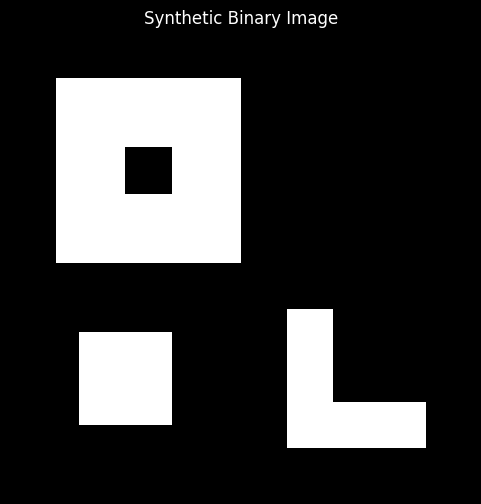

In [2]:
# Create a synthetic image with blocks, a hole, and separate objects
img = np.zeros((20, 20), dtype=np.uint8)

# Large square
img[2:10, 2:10] = 1

# Hole inside the large square
img[5:7, 5:7] = 0

# Small object
img[13:17, 3:7] = 1

# L-shape object
img[12:18, 12:14] = 1
img[16:18, 12:18] = 1

show(img, "Synthetic Binary Image")
plt.show()

# 1. Hit-or-Miss Transform

The hit-or-miss transform detects a very specific binary pattern in an image.

It is useful when we want to find:
- end points,
- corners,
- isolated pixels,
- exact local configurations.

---

## Definition

Suppose:
- $$ A $$ is the binary image,
- $$ B_1 $$ is the structuring element for foreground,
- $$ B_2 $$ is the structuring element for background.

Then the hit-or-miss transform is:

$$
A \circledast (B_1, B_2) = (A \ominus B_1) \cap (A^c \ominus B_2)
$$

This means:
- the foreground pattern must match $$ B_1 $$,
- the background pattern must match $$ B_2 $$.

So the operation is an exact pattern detector.

## Intuition

A location is marked as a match only if:
- all required foreground pixels are present, and
- all required background pixels are absent from the object.

This makes hit-or-miss stricter than standard erosion.

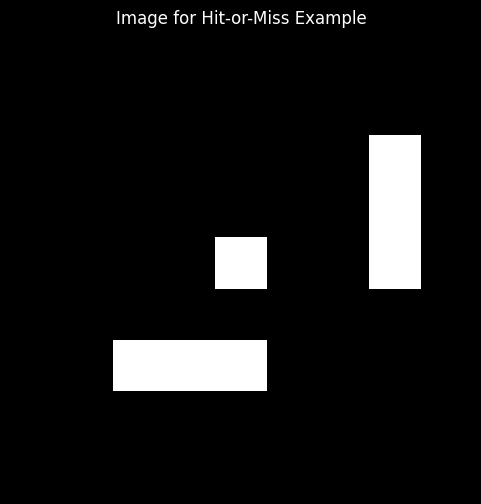

In [3]:
# Example image for hit-or-miss: detect isolated center pattern
hm_img = np.zeros((9, 9), dtype=np.uint8)
hm_img[4, 4] = 1
hm_img[2:5, 7] = 1
hm_img[6, 2:5] = 1

show(hm_img, "Image for Hit-or-Miss Example")
plt.show()

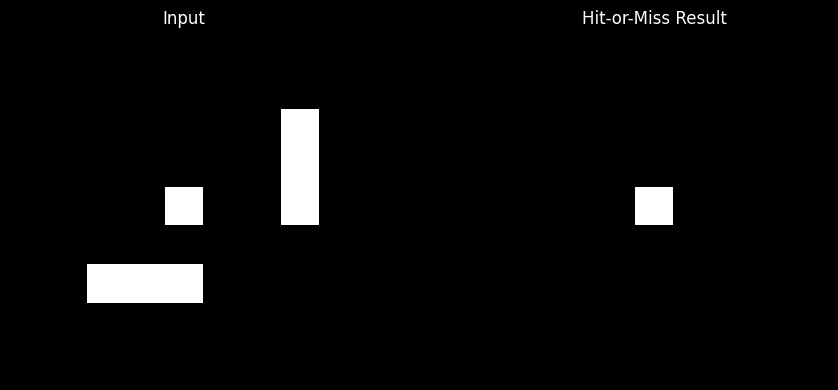

In [4]:
# Pattern: isolated single foreground pixel surrounded by background
B1 = np.array([[0,0,0],
               [0,1,0],
               [0,0,0]], dtype=bool)

# For the background mask, all 8 neighbors should be background
B2 = np.array([[1,1,1],
               [1,0,1],
               [1,1,1]], dtype=bool)

foreground_match = ndimage.binary_erosion(hm_img, structure=B1)
background_match = ndimage.binary_erosion(1 - hm_img, structure=B2)
hitmiss = foreground_match & background_match

show_pair(hm_img, hitmiss.astype(np.uint8), "Input", "Hit-or-Miss Result")
plt.show()

## Discussion

The result highlights only pixels that exactly satisfy the required foreground and background arrangement.

In this example, the transform detects the isolated single pixel, but not pixels that belong to a line.

## Student exercise: hit-or-miss for end-point detection

Modify the structuring elements so that the operation detects an end point of a line.

Hint:
- The center pixel should be foreground.
- One neighbor should also be foreground.
- Other surrounding positions should be background.

Try several orientations.

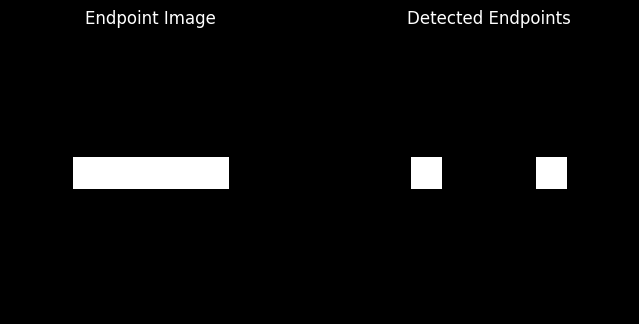

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Helper function to display images
def show_pair(img1, img2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')

    axes[1].imshow(img2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')

# Example image (horizontal line)
endpoint_img = np.zeros((9, 9), dtype=np.uint8)
endpoint_img[4, 2:7] = 1

# Structuring elements for endpoint detection

# Right endpoint →
B1_right = np.array([[0,0,0],
                     [0,1,1],
                     [0,0,0]], dtype=bool)

B2_right = np.array([[1,1,1],
                     [1,0,0],
                     [1,1,1]], dtype=bool)

# Left endpoint ←
B1_left = np.array([[0,0,0],
                    [1,1,0],
                    [0,0,0]], dtype=bool)

B2_left = np.array([[1,1,1],
                    [0,0,1],
                    [1,1,1]], dtype=bool)

# Up endpoint ↑
B1_up = np.array([[0,1,0],
                  [0,1,0],
                  [0,0,0]], dtype=bool)

B2_up = np.array([[1,0,1],
                  [1,0,1],
                  [1,1,1]], dtype=bool)

# Down endpoint ↓
B1_down = np.array([[0,0,0],
                    [0,1,0],
                    [0,1,0]], dtype=bool)

B2_down = np.array([[1,1,1],
                    [1,0,1],
                    [1,0,1]], dtype=bool)

# List of all orientations
patterns = [
    (B1_right, B2_right),
    (B1_left, B2_left),
    (B1_up, B2_up),
    (B1_down, B2_down)
]

# Apply hit-or-miss for all orientations
result = np.zeros_like(endpoint_img, dtype=bool)

for B1, B2 in patterns:
    fg = ndimage.binary_erosion(endpoint_img, structure=B1)
    bg = ndimage.binary_erosion(1 - endpoint_img, structure=B2)
    result |= (fg & bg)

# Show result
show_pair(endpoint_img, result.astype(np.uint8),
          "Endpoint Image", "Detected Endpoints")

plt.show()

# 2. Boundary Extraction

Boundary extraction finds the border pixels of an object.

---

## Equation

If $$ A $$ is the binary image and $$ B $$ is a structuring element, the boundary of $$ A $$ is:

$$
\beta(A) = A - (A \ominus B)
$$

### Interpretation
- $$ A \ominus B $$ removes one layer of pixels from the object.
- Subtracting the eroded image from the original leaves the boundary.

This is a simple and very common way to isolate the outer contour of binary objects.

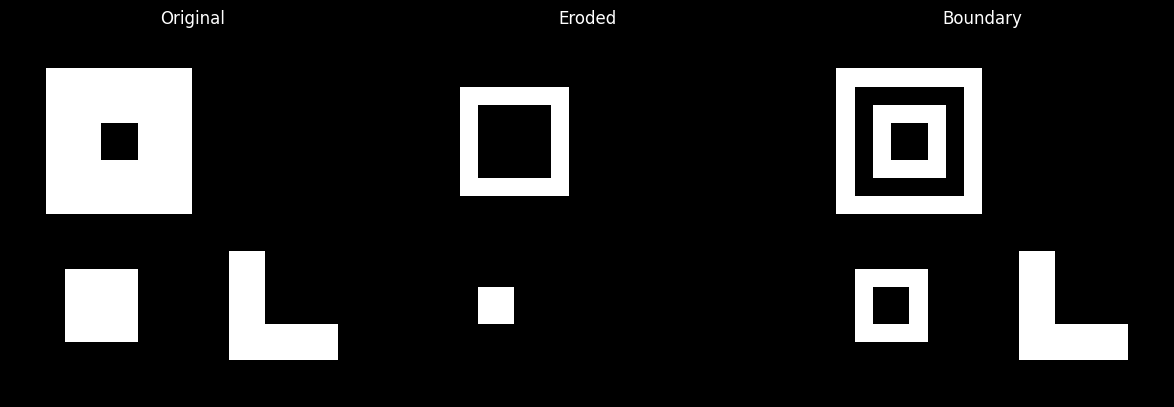

In [7]:
se = np.ones((3, 3), dtype=bool)
eroded = ndimage.binary_erosion(img, structure=se)
boundary = img & (~eroded)

show_triplet(img, eroded.astype(np.uint8), boundary.astype(np.uint8),
             "Original", "Eroded", "Boundary")
plt.show()

## Observation

The erosion shrinks the object.  
The pixels removed during this shrinking process form the boundary.

## Student exercise: compare boundary thickness

Try different structuring elements:
- 3x3 square
- cross-shaped element
- 5x5 square

Question:
How does the boundary change when the structuring element becomes larger?

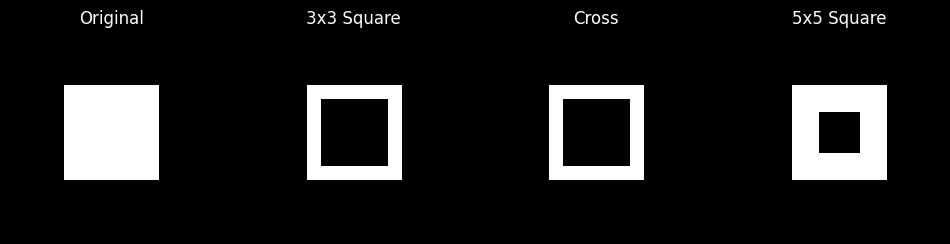

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Helper to show multiple images
def show_images(images, titles):
    fig, axes = plt.subplots(1, len(images), figsize=(12, 4))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.show()

# Example binary image (rectangle)
img = np.zeros((15, 15), dtype=np.uint8)
img[4:11, 4:11] = 1

# Structuring elements
square_3 = np.ones((3, 3), dtype=bool)

cross = np.array([[0,1,0],
                  [1,1,1],
                  [0,1,0]], dtype=bool)

square_5 = np.ones((5, 5), dtype=bool)

# Function to compute boundary: A - erosion(A)
def boundary(image, structure):
    eroded = ndimage.binary_erosion(image, structure=structure)
    return image - eroded

# Compute boundaries
b1 = boundary(img, square_3)
b2 = boundary(img, cross)
b3 = boundary(img, square_5)

# Show results
show_images(
    [img, b1, b2, b3],
    ["Original", "3x3 Square", "Cross", "5x5 Square"]
)

# 3. Hole Filling

Hole filling is used to fill interior background regions that are fully surrounded by foreground.

A **hole** is a background region that is not connected to the image border.

---

## Morphological formulation

Let:
- $$ A $$ be the foreground object set,
- $$ A^c $$ be the background,
- $$ X_0 $$ be a seed point inside a hole.

Then iterative geodesic dilation can be used:

$$
X_k = (X_{k-1} \oplus B) \cap A^c
$$

Repeat until stability:

$$
X_k = X_{k-1}
$$

Then the filled image is:

$$
A_{\text{filled}} = A \cup X_k
$$

This means we grow a region from a seed inside the hole, but constrain the growth so it remains inside the background hole.

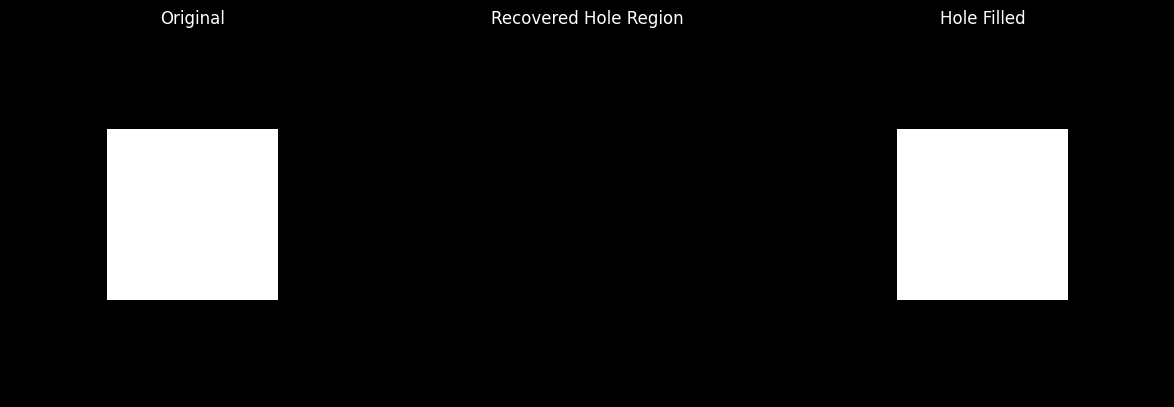

In [10]:
# Use a seed inside the hole of the large square
seed = np.zeros_like(img, dtype=bool)
seed[5, 5] = True  # seed inside hole

background = ~img.astype(bool)
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]], dtype=bool)

X_prev = seed.copy()

while True:
    X_next = ndimage.binary_dilation(X_prev, structure=structure) & background
    if np.array_equal(X_next, X_prev):
        break
    X_prev = X_next

filled_hole_region = X_prev
filled_img = img.astype(bool) | filled_hole_region

show_triplet(img, filled_hole_region.astype(np.uint8), filled_img.astype(np.uint8),
             "Original", "Recovered Hole Region", "Hole Filled")
plt.show()

## Alternative idea

A practical strategy for full hole filling is:
1. Mark the background connected to the border.
2. Any background not connected to the border is a hole.
3. Convert those holes to foreground.

This is often how hole filling is implemented in practice.

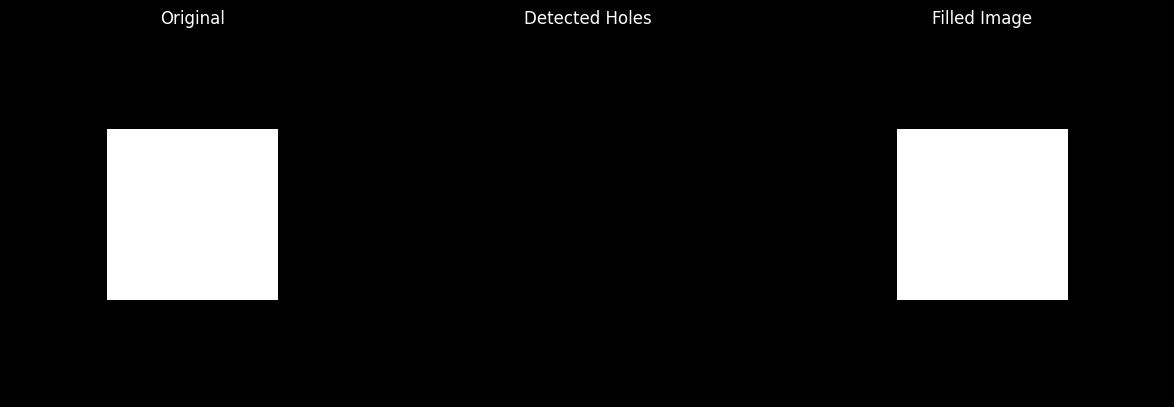

In [11]:
# Border-based hole filling
inv = 1 - img
seed_border = np.zeros_like(inv, dtype=bool)

seed_border[0, :] = inv[0, :]
seed_border[-1, :] = inv[-1, :]
seed_border[:, 0] = inv[:, 0]
seed_border[:, -1] = inv[:, -1]

outside = seed_border.copy()
while True:
    grown = ndimage.binary_dilation(outside, structure=structure) & inv.astype(bool)
    if np.array_equal(grown, outside):
        break
    outside = grown

holes = inv.astype(bool) & (~outside)
filled_by_border = img.astype(bool) | holes

show_triplet(img, holes.astype(np.uint8), filled_by_border.astype(np.uint8),
             "Original", "Detected Holes", "Filled Image")
plt.show()

## Student exercise: multiple holes

Create a new image with:
- two separate holes,
- one gap that touches the border.

Then test whether the algorithm fills only the true holes and not the border-connected background.

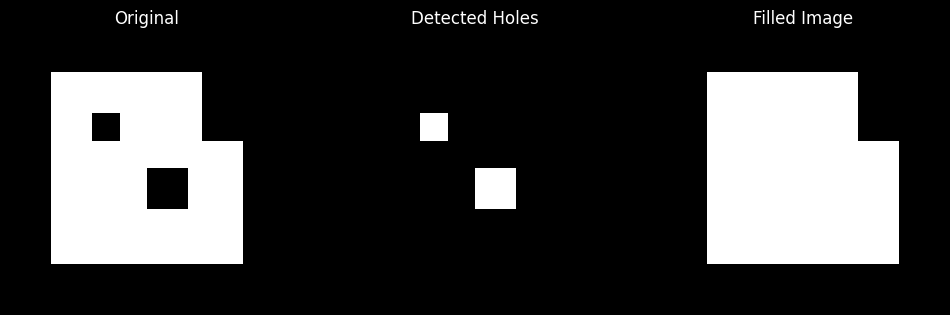

In [13]:
# Student task cell: build your own image here
student_holes = np.zeros((20, 20), dtype=np.uint8)
student_holes[3:17, 3:17] = 1
student_holes[6:8, 6:8] = 0
student_holes[10:13, 10:13] = 0
student_holes[3:8, 14:17] = 0  # border-connected gap because it touches outer object boundary

inv = 1 - student_holes

# Step 2: Marker (start from border)
marker = np.zeros_like(inv)
marker[0, :] = inv[0, :]
marker[-1, :] = inv[-1, :]
marker[:, 0] = inv[:, 0]
marker[:, -1] = inv[:, -1]

# Step 3: Reconstruction (propagate background)
prev = np.zeros_like(marker)
structure = np.ones((3, 3), dtype=bool)

while not np.array_equal(marker, prev):
    prev = marker.copy()
    marker = ndimage.binary_dilation(marker, structure=structure)
    marker = marker & inv

# Step 4: Holes = not reached background
holes = inv & (~marker)

# Step 5: Fill holes
filled = student_holes | holes

# --- Show results ---
show_images(
    [student_holes, holes.astype(np.uint8), filled.astype(np.uint8)],
    ["Original", "Detected Holes", "Filled Image"]
)

# 4. Extraction of Connected Components

Connected component extraction isolates all pixels belonging to one connected object.

This is essential for:
- object counting,
- measuring area,
- segmentation post-processing,
- keeping only the largest object,
- removing small noise components.

---

## Morphological formulation from a seed

Let \( A \) be a binary image, and let \( X_0 \) be a seed inside one component.

Then:

$$
X_k = (X_{k-1} \oplus B) \cap A
$$

Repeat until stability:

$$
X_k = X_{k-1}
$$

The final set $$ X_k $$ is the connected component containing the seed.

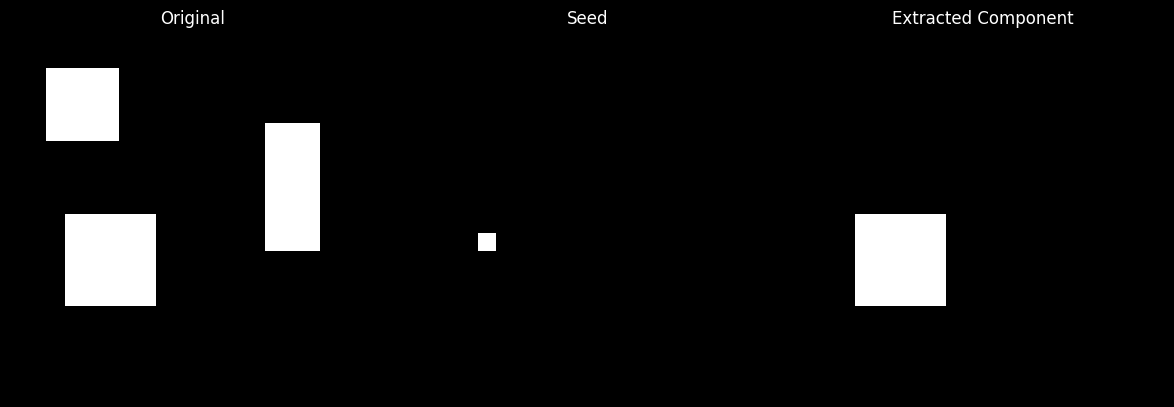

In [14]:
cc_img = np.zeros((20, 20), dtype=np.uint8)
cc_img[2:6, 2:6] = 1
cc_img[10:15, 3:8] = 1
cc_img[5:12, 14:17] = 1

seed_component = np.zeros_like(cc_img, dtype=bool)
seed_component[11, 4] = True  # inside second component

component = seed_component.copy()
while True:
    grown = ndimage.binary_dilation(component, structure=structure) & cc_img.astype(bool)
    if np.array_equal(grown, component):
        break
    component = grown

show_triplet(cc_img, seed_component.astype(np.uint8), component.astype(np.uint8),
             "Original", "Seed", "Extracted Component")
plt.show()

## Using automatic labeling

Instead of manually providing a seed, we can label all connected components automatically.

Number of connected components: 3
Labels present: [0 1 2 3]


C:\Users\sudob\AppData\Local\Temp\ipykernel_7756\1376084510.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)


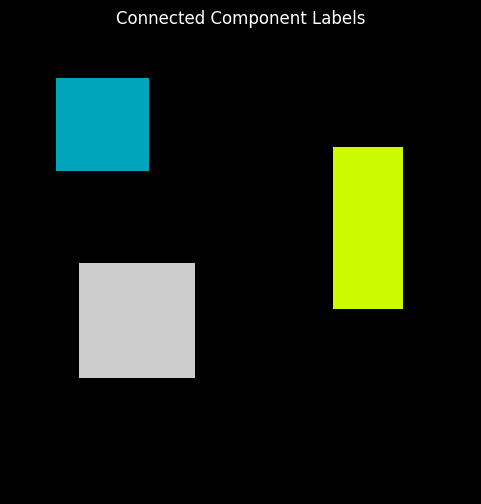

In [15]:
labeled, num_features = ndimage.label(cc_img)

print("Number of connected components:", num_features)
print("Labels present:", np.unique(labeled))

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)
ax.imshow(labeled, cmap=cmap)
ax.set_title("Connected Component Labels")
ax.axis("off")
plt.show()

## Student exercise: measure connected components

Write code to compute:
- number of connected components,
- area of each component,
- largest component only.

Then display only the largest component as a binary image.

Number of connected components: 3
Areas of components: [16. 21. 25.]
Largest component label: 3
Largest component area: 25.0


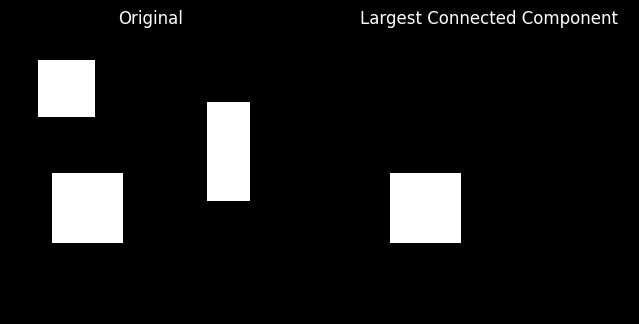

In [16]:
# Student task cell: measure areas and extract largest component
labeled_student, n_student = ndimage.label(cc_img)

print("Number of connected components:", n_student)

# --- Compute areas of each component ---
areas = ndimage.sum(cc_img, labeled_student, index=range(1, n_student + 1))

print("Areas of components:", areas)

# --- Find largest component ---
largest_label = np.argmax(areas) + 1
largest_component = (labeled_student == largest_label).astype(np.uint8)

print("Largest component label:", largest_label)
print("Largest component area:", areas[largest_label - 1])

# --- Display ---
def show_pair(img1, img2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')

    axes[1].imshow(img2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')

show_pair(cc_img, largest_component, "Original", "Largest Connected Component")
plt.show()

# Comparison Summary

| Operation | Main Idea | Key Equation |
|---|---|---|
| Hit-or-Miss | Detect exact local pattern | $$(A \ominus B_1) \cap (A^c \ominus B_2)$$ |
| Boundary Extraction | Remove inner pixels, keep border | $$A - (A \ominus B)$$ |
| Hole Filling | Fill enclosed background regions | $$X_k = (X_{k-1} \oplus B) \cap A^c$$ |
| Connected Components | Grow one object from a seed | $$X_k = (X_{k-1} \oplus B) \cap A$$ |

---

## Common exam-style questions

1. Why is hit-or-miss considered a strict pattern detector?
2. Why does boundary extraction use erosion and subtraction?
3. What is the difference between a hole and ordinary background?
4. Why does connected component extraction require a seed in the classical iterative formulation?
5. How does 4-connectivity differ from 8-connectivity?

# Mini project for students

Create your own binary image containing:
- at least three objects,
- one hole,
- one thin line,
- one isolated point.

Then complete the following tasks:

1. Detect the isolated point using hit-or-miss.
2. Extract the boundaries of all objects.
3. Fill the hole.
4. Label all connected components.
5. Report the area of each connected component.

This project combines all four techniques into one workflow.

Number of components: 4
Areas: [64.  1. 25.  7.]


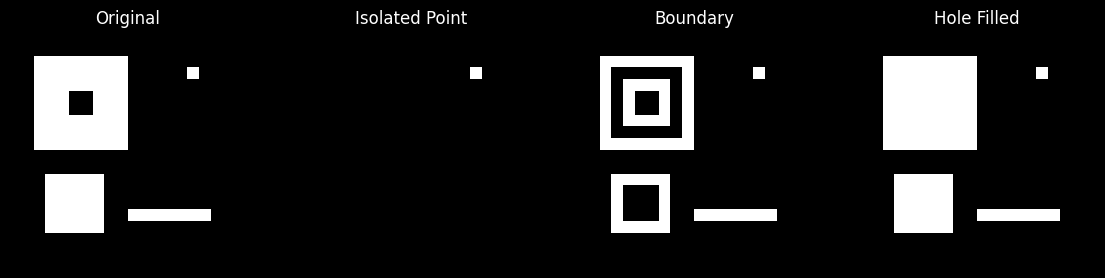

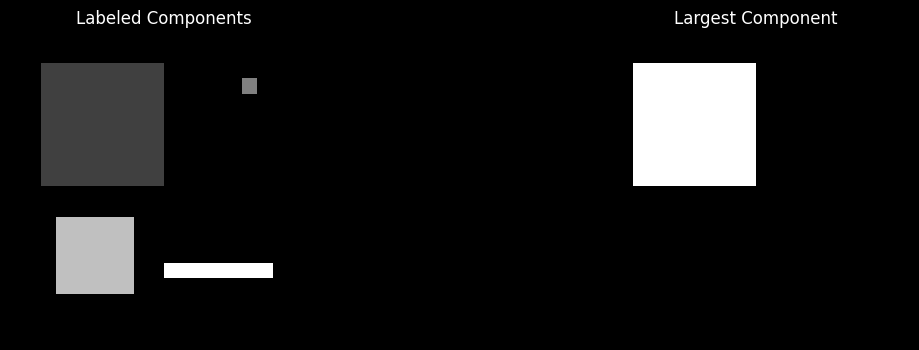

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# ---------- Helper functions ----------
def show_images(images, titles):
    fig, axes = plt.subplots(1, len(images), figsize=(14, 4))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.show()

# ---------- 1. Create custom image ----------
img = np.zeros((20, 20), dtype=np.uint8)

# Object 1: square with a hole
img[2:10, 2:10] = 1
img[5:7, 5:7] = 0  # hole

# Object 2: rectangle
img[12:17, 3:8] = 1

# Object 3: thin horizontal line
img[15, 10:17] = 1

# Isolated point
img[3, 15] = 1

# ---------- 2. Detect isolated point (hit-or-miss) ----------
B1 = np.array([[0,0,0],
               [0,1,0],
               [0,0,0]], dtype=bool)

B2 = np.array([[1,1,1],
               [1,0,1],
               [1,1,1]], dtype=bool)

fg = ndimage.binary_erosion(img, structure=B1)
bg = ndimage.binary_erosion(1 - img, structure=B2)
isolated = fg & bg

# ---------- 3. Extract boundaries ----------
structure = np.ones((3, 3), dtype=bool)
eroded = ndimage.binary_erosion(img, structure=structure)
boundary = img - eroded

# ---------- 4. Fill holes ----------
filled = ndimage.binary_fill_holes(img).astype(np.uint8)

# ---------- 5. Connected components ----------
labeled, num = ndimage.label(filled)

areas = ndimage.sum(filled, labeled, index=range(1, num + 1))

print("Number of components:", num)
print("Areas:", areas)

# ---------- Display results ----------
show_images(
    [img, isolated.astype(np.uint8), boundary, filled],
    ["Original", "Isolated Point", "Boundary", "Hole Filled"]
)

# Show largest component (optional)
largest_label = np.argmax(areas) + 1
largest = (labeled == largest_label).astype(np.uint8)

show_images(
    [labeled, largest],
    ["Labeled Components", "Largest Component"]
)

# Apply all methods with reading an image

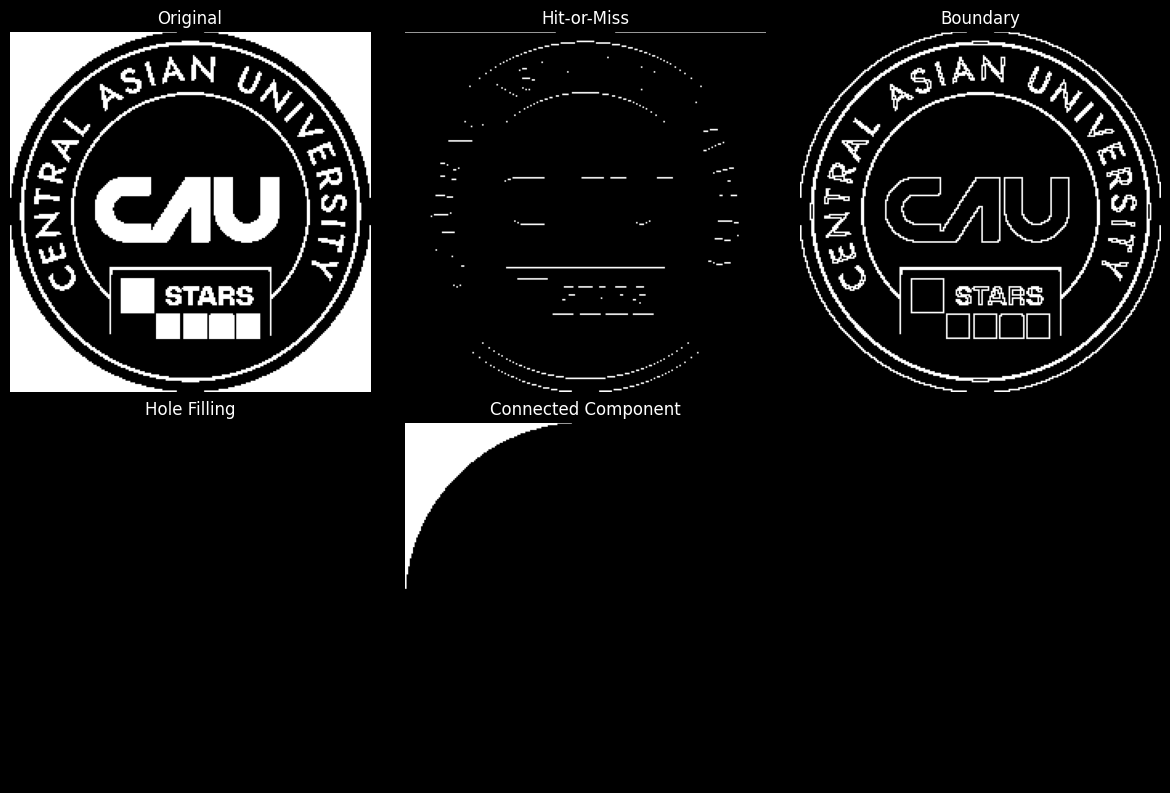

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week12/images.png", 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Hit-or-Miss
binary01 = (binary // 255).astype(np.uint8)
kernel = np.array([[-1,-1,-1],
                   [ 0, 1, 0],
                   [ 1, 1, 1]], dtype=np.int8)
hitmiss = cv2.morphologyEx(binary01, cv2.MORPH_HITMISS, kernel) * 255

# Boundary Extraction
se = np.ones((3,3), np.uint8)
boundary = cv2.subtract(binary, cv2.erode(binary, se))

# Hole Filling
mask = np.zeros((binary.shape[0]+2, binary.shape[1]+2), np.uint8)
flood = binary.copy()
cv2.floodFill(flood, mask, (0,0), 255)
holes = cv2.bitwise_not(flood)
filled = cv2.bitwise_or(binary, holes)

# Connected Components
num_labels, labels = cv2.connectedComponents(binary)
component = np.zeros_like(binary)
if num_labels > 1:
    component[labels == 1] = 255

# Display
plt.figure(figsize=(12,8))
plt.subplot(231), plt.imshow(binary, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(232), plt.imshow(hitmiss, cmap='gray'), plt.title("Hit-or-Miss"), plt.axis("off")
plt.subplot(233), plt.imshow(boundary, cmap='gray'), plt.title("Boundary"), plt.axis("off")
plt.subplot(234), plt.imshow(filled, cmap='gray'), plt.title("Hole Filling"), plt.axis("off")
plt.subplot(235), plt.imshow(component, cmap='gray'), plt.title("Connected Component"), plt.axis("off")
plt.tight_layout()
plt.show()